# Supplementary Figures S2–S3: AGIST

Recalculate the plotted summaries and rebuild both figures from the packaged processed inputs. This compact workflow does not run model training or regenerate the processed inputs.

## Reproduction route

This route states where the plotted values begin, how the upstream analysis is
run when it is available, and what this notebook does not recalculate.

In [1]:
from CytoBridge.results import describe_figure_workflow

route = describe_figure_workflow('agist')
{
    key: route[key]
    for key in (
        "paper_location",
        "mode",
        "starts_from",
        "upstream_entry",
        "upstream_command",
        "figure_command",
        "scope",
    )
}

{'paper_location': 'Supplementary Figures S2-S3',
 'mode': 'numeric-redraw',
 'starts_from': 'Packaged cell-level summaries, processed simulation arrays, and tables.',
 'upstream_entry': 'package resource: agist_figures/full_recompute_inputs.csv',
 'upstream_command': None,
 'figure_command': 'cytobridge figure agist --output-dir outputs/agist',
 'scope': 'Redraws S2-S3. Simulation generation, model fitting, and rollout are external to the wheel.'}

## Load the compact figure data

In [2]:
from pathlib import Path

from IPython.display import Image, display

from CytoBridge.results import (
    calculate_agist_figure_panels,
    load_agist_figures,
    plot_agist_figures,
    write_agist_figure_tables,
)

output_dir = Path("outputs") / "agist_figures"
output_dir.mkdir(parents=True, exist_ok=True)
data = load_agist_figures()

### Inputs needed before the S2–S3 redraw

The compact package contains the numerical values used by the plotting cells.
The table below lists the simulation data, model configuration, checkpoint,
and rollout files needed to rebuild those compact values. Those external files
are not generated in this notebook.

In [3]:
display(data.full_recompute_inputs)

,figure,role,relative_identifier,availability
0,S2,velocity component archive A,ebfb921b-884a-4aad-b4e3-99ae9b8a512d.zip,external
1,S2,velocity component archive B,ed999aeb-bfe3-4426-8c04-3ee56f094b81.zip,external
2,S2,simulation time table,mouse_brain_simulation.csv,external
3,S2,state partition assignments,agist_state_cluster_assignments.csv,external
4,S2,state partition selection,s2_cluster_selection_diagnostics.csv,bundled
5,S3,simulation training input,attractive_observed.h5ad,external
6,S3,trained model checkpoint,Score_Refine/best_model.pth,external
7,S3,model configuration,training/config.yaml,external
8,S3,full trajectory rollout,evaluation_fixed400_five_seed/dense_rollout_se...,external
9,S3,processed snapshot display,s3_observed_snapshots.npz,bundled


## Recalculate the panel tables

In [4]:
panels = calculate_agist_figure_panels(data)
tables = write_agist_figure_tables(panels, output_dir)
{name: path.name for name, path in tables.items()}

{'s2_by_time': 's2_velocity_by_time.csv',
 's2_by_cluster': 's2_velocity_by_state_cluster.csv',
 's2_overall': 's2_velocity_overall.csv',
 's2_time_cluster': 's2_velocity_by_time_and_state_cluster.csv',
 's3_growth': 's3_growth_summary.csv',
 's3_potential': 's3_potential_curve.csv',
 's3_ablation': 's3_ablation_summary.csv'}

## Rebuild the PDF and PNG files

In [5]:
figures = plot_agist_figures(data, panels, output_dir)
{
    figure: {"pdf": paths[0].name, "png": paths[1].name}
    for figure, paths in figures.items()
}

{'s2': {'pdf': 'supplementary_figure_s2.pdf',
  'png': 'supplementary_figure_s2.png'},
 's3': {'pdf': 'supplementary_figure_s3.pdf',
  'png': 'supplementary_figure_s3.png'}}

## Preview the reproduced figures

S2


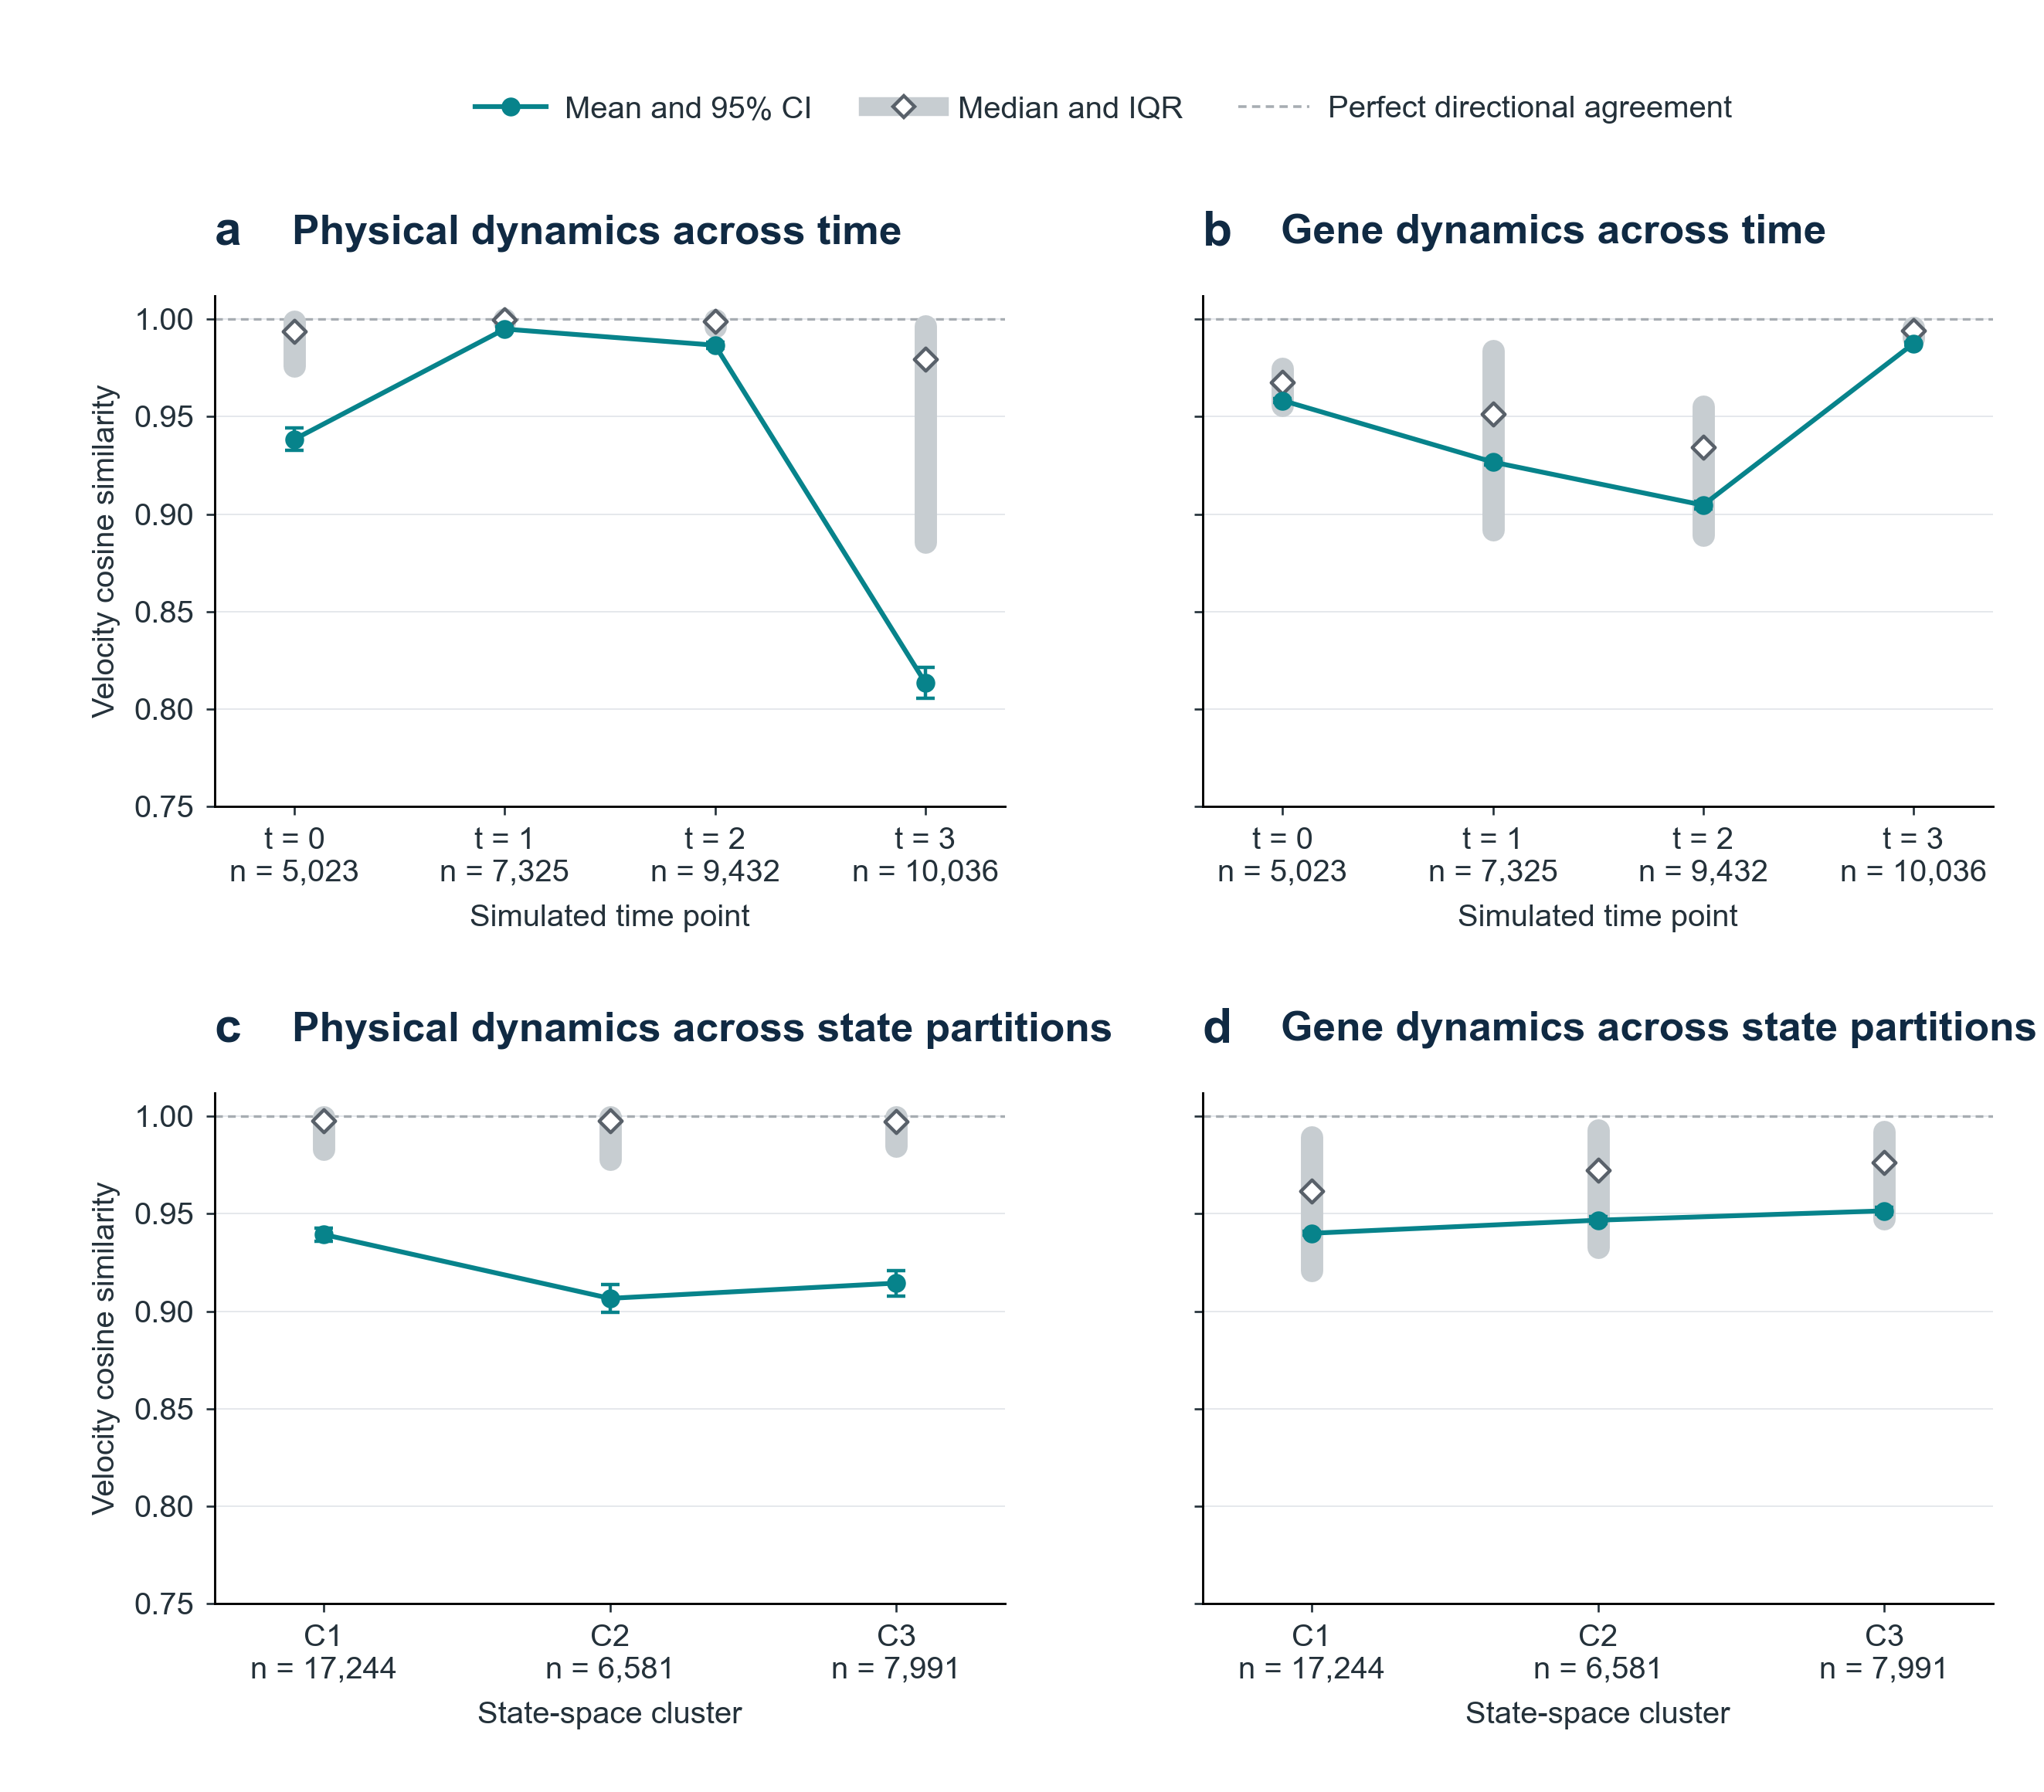

S3


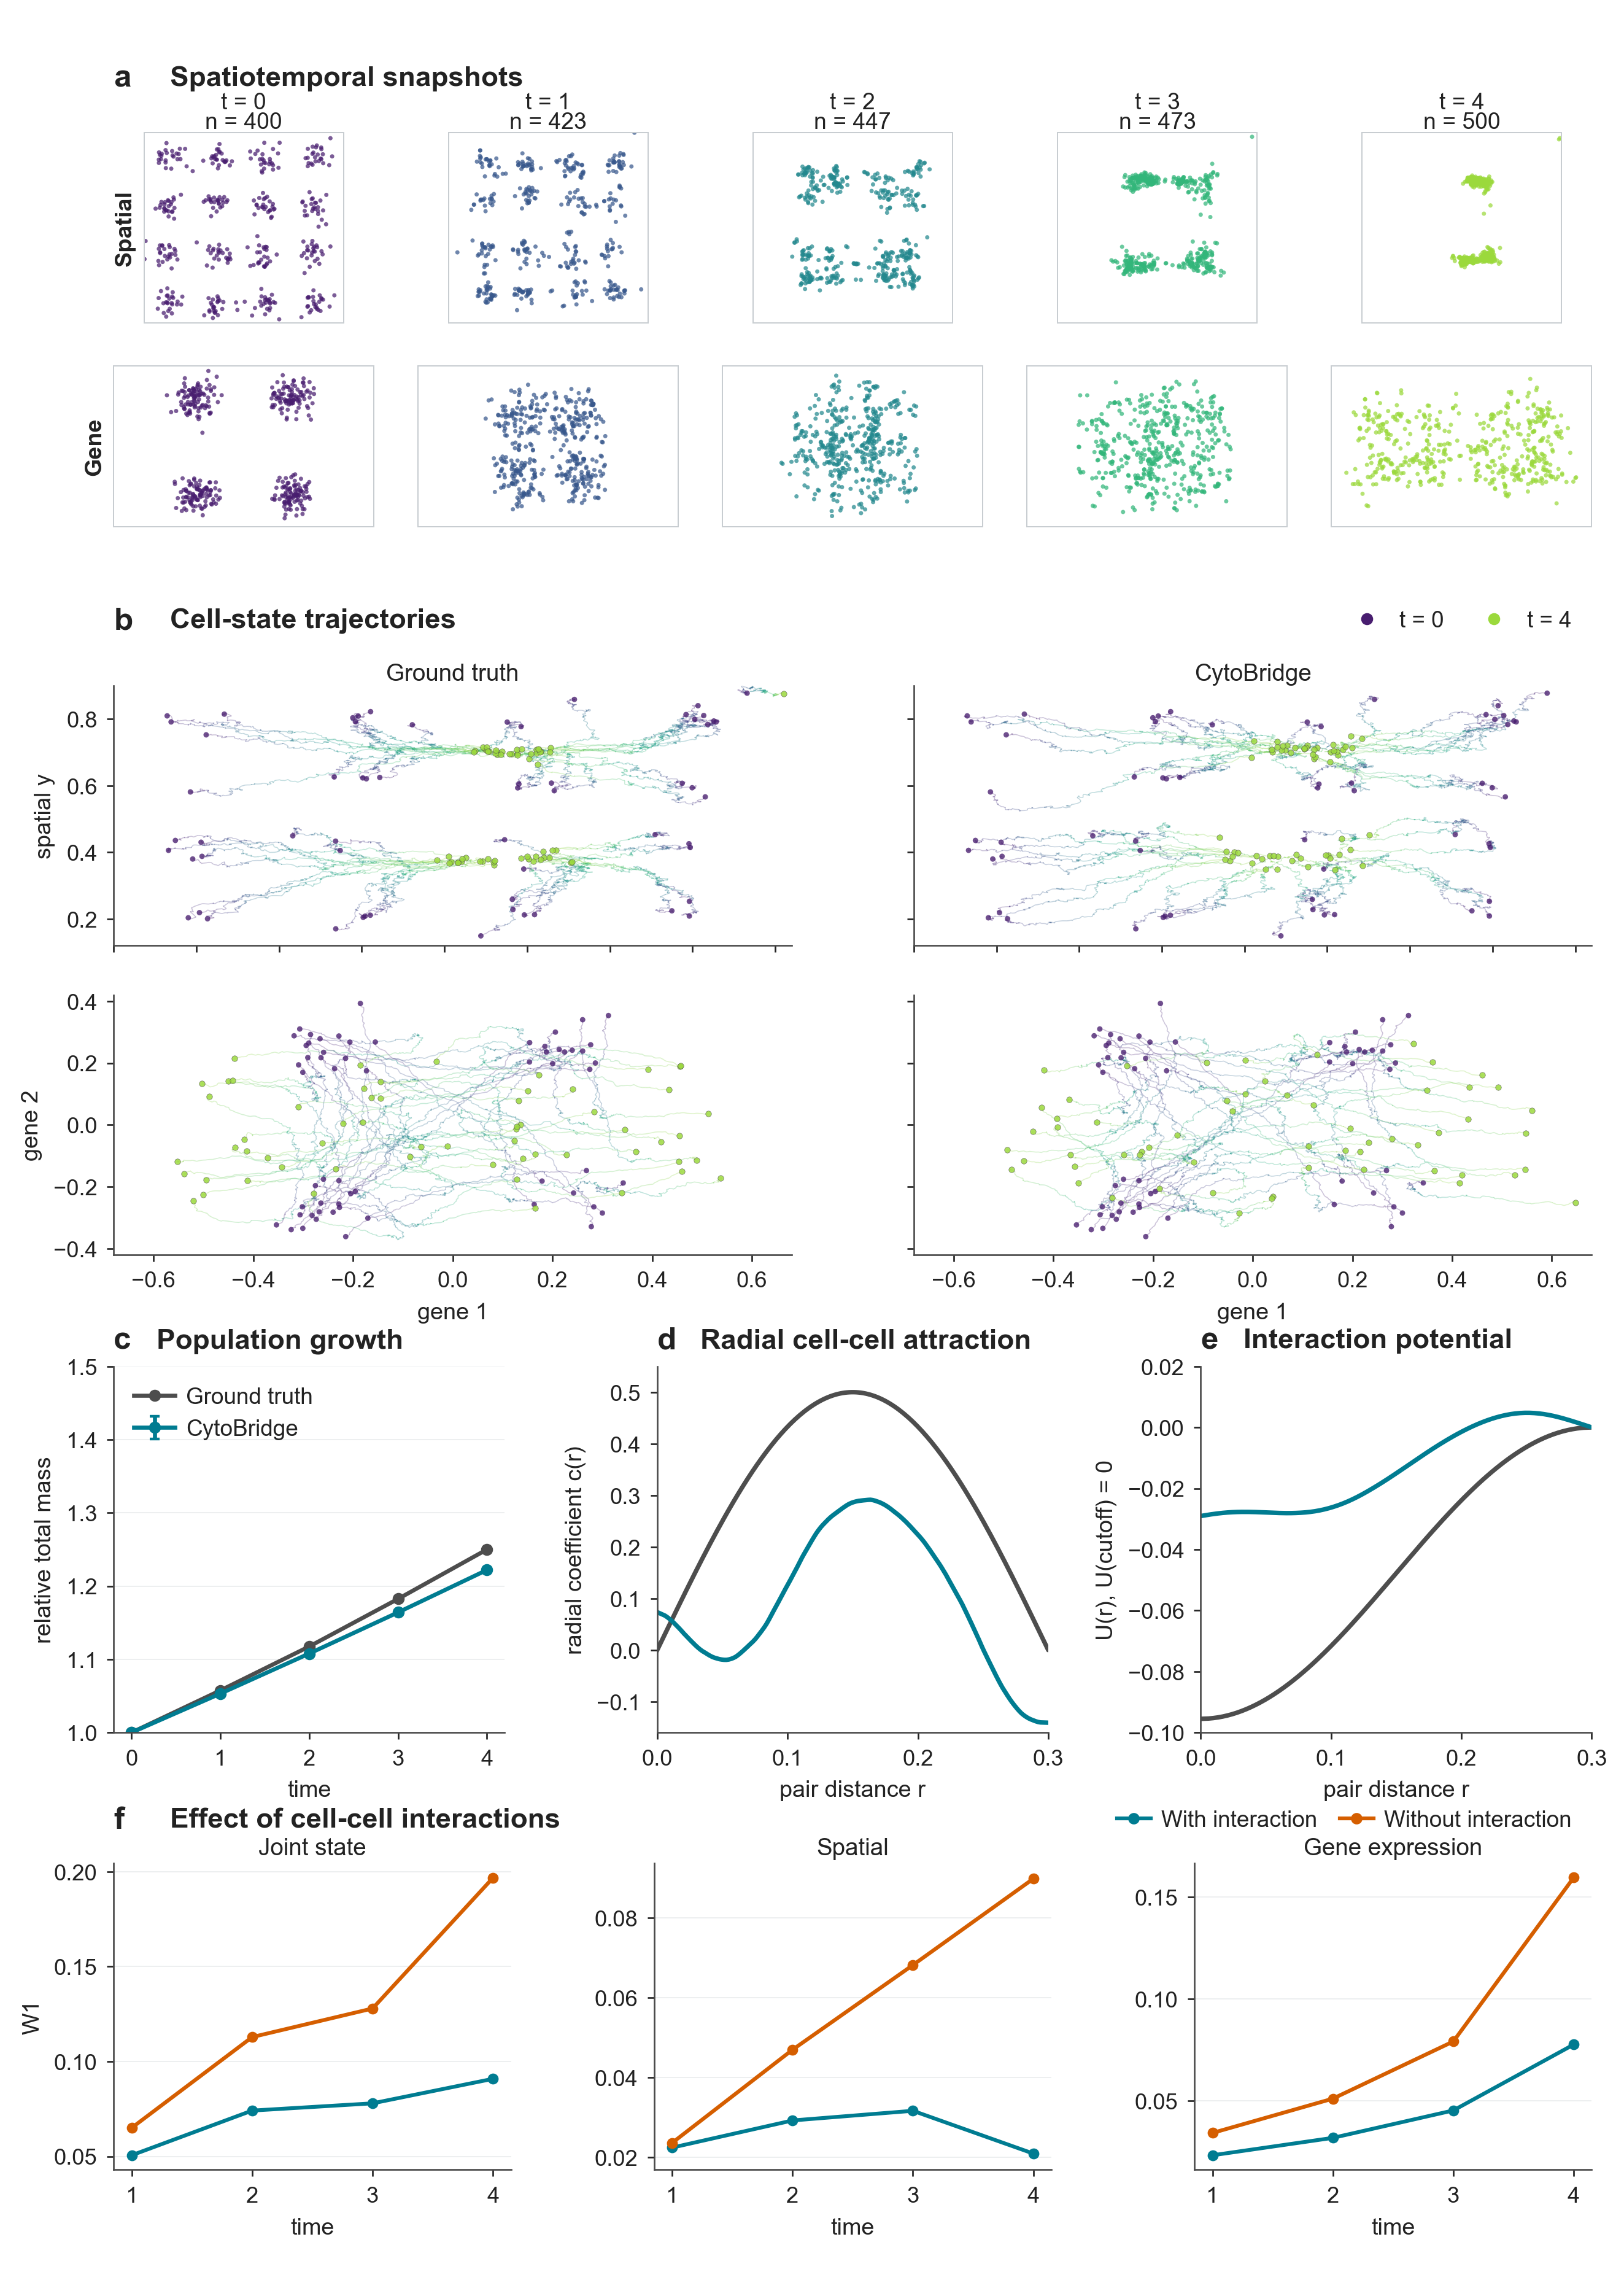

In [6]:
for figure, (_, png_path) in figures.items():
    print(figure.upper())
    display(Image(filename=str(png_path), width=720))